# 11. Fault-tolerant Workflows

## 11.01. `POST /admin/newsletters` - A refreshser

##### 11.01.0.0. Skimming: What did you notice and why? Any Questions

**What?**  
- We we want a **best effort newsletter delivery**: where the newsletter is delivered to all confirmed subscribers with minimal duplicate deliveries
- Recap of our `publish_newsletter` handler that is responsible for our newsletter delivery.

**Why?**  
- Our application as of now is susceptible to transient failures like
    - Application crashes
    - PostMark errors
    - network failures 
- Because we
    1. Fetch all subscribers from the database
    2. Loop over all the subscribers and send the newsletter issue one by one
    
  What happens when one of the email sends causes an application crash or PostMark error? We end up in a situation where the newsletter is delivered to  
  some subscribers and not to others. We also have no idea who received and who didn't and why. Additionally we have no mechanism in place to retry delivery
  of only the failures.


**Questions?**  
Why can we not rule out duplicate delivery entirely?  
> Look out for where this is discussed


##### 11.01.0.1. Deep Dive: Summarize, ELI5, Connect

## 11.2. Our Goal

A **best-effort delivery**.

## 11.3. Failure Modes

##### 11.03.0.0. Skimming: What did you notice and why? Any Questions

**What?**  
- 4 main types of failure modes
    1. Invalid Inputs - We are using the `Form` extractor and redirect back to the `publish_newsletter_form`. Currently not bad. In the future
       we might have more advanced validation requirements
    2. Network I/O
       - Postgres - Did postgress fail before we had fetched all the confirmed subscribers or all.
       - Postmark API  - Did our postmark email delivery fail at the first confirmed subscriber or at the $m-n+1$ subscriber.
         > Where $m \rightarrow$ total number of subscribers  
         > & $n \rightarrow$ subscribers to whom newsletters where delivered successfully.
    3. Application Crashes - Since we are hosting our application in the cloud, there may be an issue with our cloud provider servers leading to issues
       with our application. When sending the newsletter we have no visibility currently at what point our server crashed. It might have been at n-1 confirmed
       subscriber email send.
    4. Author actions - We don't have a mechanism of showing current newsletter delivery progress, so an author might click publish multiple times if they are
       not getting feedback from the application. I.e. our application is currently not retry safe.


**Why?**  
Really important considerations for making our `publish_newsletter` endpoint retry safe and **idempotent**.


**Questions?**  
None

##### 11.03.0.1. Deep Dive: Summarize, ELI5, Connect

### 11.3.1. Invalid Inputs.

### 11.3.2. Network I/O

### 11.3.3. Application Crashes

### 11.3.4. Author Actions

## 11.4. Idempotency: An Introduction

##### 11.04.0.0. Skimming: What did you notice and why? Any Questions

**What?**  
- Idempotency definition
  > **Mine**  
  > The property of an operation or a function call resulting in to the same initial outcome/result regardless of multiple repeated calls  
  > e.g. $1\times1$ is idempotent. $1 + 1$ is not.
  >
  > **Google**  
  > The property of certain operations or functions where applying them multiple times has the same exact effect as applying them just once.
  >
  > **Book**  
  > An API endpoint is idempotent(or _**retry-safe**_) if the caller has no way to **observe** if a request
  > has been sent to the server once or multiple times.

- How can we distinguish between a user retry and a distinct separate call? The caller generates an idempotency key that helps the server more easily distinguish the caller's intent.

- Concurrent requests? $\rightarrow$ we introduce **synchronization** the secode request should not be processed until the first one has completed.

**Why?**  
I've seen the terminology multiple times and had a sense of what it meant now I can be sure.

**Question**  
None

##### 11.04.0.1. Deep Dive: Summarize, ELI5, Connect

### 11.4.0. Overview.

### 11.4.1. Idempotency In Action: Payments

### 11.4.2. Idempotency Keys

### 11.4.3. Concurrent Request

## 11.5. Requirements As Tests #1

##### 11.05.0.0. Skimming: What did you notice and why? Any Questions

**What?**  
- `app.test_user.login()` in the `newsletter_creation_is_idempotent` test.
- `expected(1)` in the the `Mock`
- 2 `post_publish_newsletter` requests with the same `newsletter_request_body`


**Why?**  
- Had been thinking about creating a helper method around authenticated route testing. Also it interesting how `TestApp` has a dependency on `TestUser`
  and `TestUser`'s  `login` method has a dependency on `TestApp`. I guess because we are using componsition instead of inheritance we don't get any issues.
- We expect that our `Mock` email server will only receive a request once if our implememntation is idempotent.
- The 2nd `post_publish_newsletter` request is how we test a retry and **retry-safety**.

**Questions?**  



##### 11.05.0.1. Deep Dive: Summarize, ELI5, Connect

**Summary**  
We write our first test for asserting idepontency for synchronous requests, where the original request is processed fully before the second retry is received.  


**Implementation**  
We introduce `login` method for `TestUser`.
```Rust
// tests/api/helper.rs
// [...]

// [...]

impl TestUser {
    pub async fn login(&self, app: &TestApp) {
        app.post_login(&serde_json::json!({
            "username": &self.username,
            "password": &self.password,
        })).await;
    }
    // [...]
}
```
We then add the `newsletter_creation_is_idempotent` test.
```Rust
// tests/api/newsletter.rs
// [...]
use uuid::Uuid;

#[tokio::test]
async fn newsletter_creation_is_idempotent() {
    // Arrange
    let app = spawn_app().await;
    app.test_user.login(&app).await;
    create_confirmed_subscriber(&app).await;
    let newletter_request = serde_json::json!({
        "title": "Newsletter title",
        "txt_content": "Newsletter content",
        "idempotency_key": Uuid::now_v7().to_string(),
    });
    
    // Act
    Mock::given(path("/email"))
        .and(method("POST"))
        .respond_with(ResponseTemplate::new(200))
        .expect(1) // -> This is asserted on drop.
        .mount(&app.email_server)
        .await;
    
    // Act & Assert 1 - 1st successful publish and flash message rendered
    let response = app.post_publish_newsletter(&newsletter_request).await;
    assert_on_rediret(&response, "/admin/publish_newsletter");
    let publish_newsletter_html = app.get_publish_newsletter_html().await;
    assert!(
        publish_newsletter_html
            .contains(r#"<p><i>Newsletter Issue Published Successfully.</i></p>"#)
    );
    
    // Act & Assert 2 - 2nd successful publish and flash message rendered
    let response = app.post_publish_newsletter(&newsletter_request).await;
    assert_on_rediret(&response, "/admin/publish_newsletter");
    let publish_newsletter_html = app.get_publish_newsletter_html().await;
    assert!(
        publish_newsletter_html
            .contains(r#"<p><i>Newsletter Issue Published Successfully.</i></p>"#)
    );
 
    // Assert 3 - Mock asserts on Drop that the newsletter email was sent only **once**
    
}
```

The test should fail. We get 2 email send requests instead of 1.

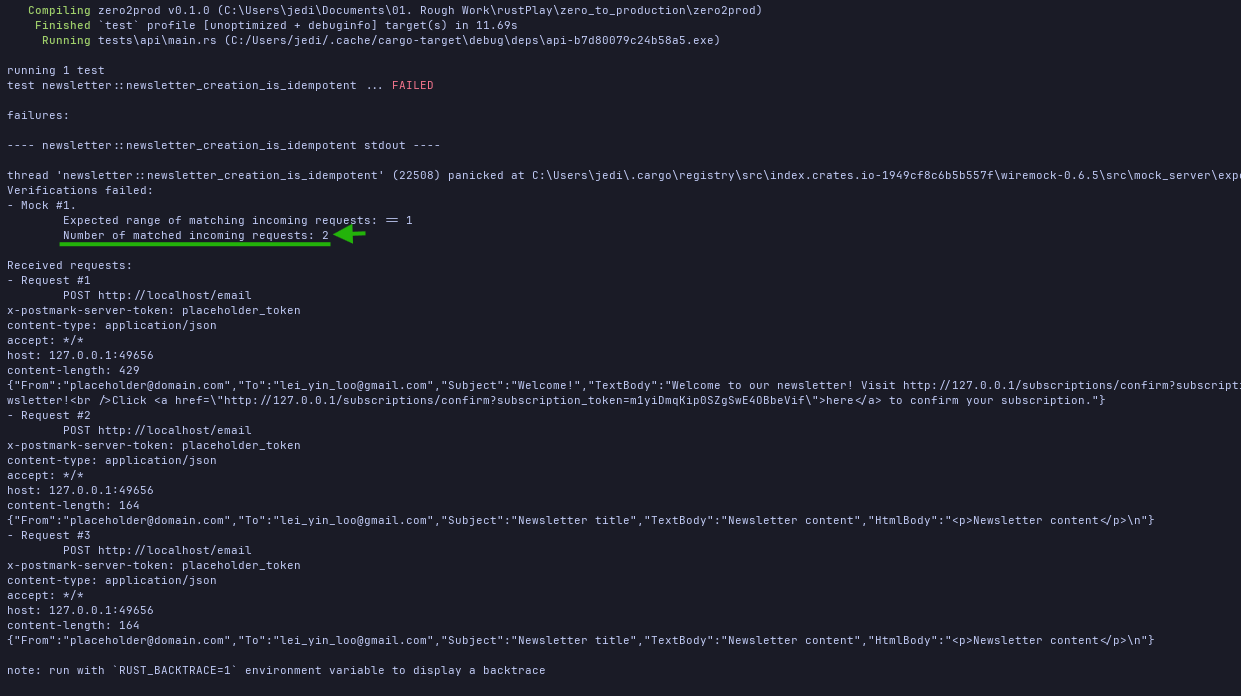

## 11.6. Implementation Strategies

##### 11.06.0.0. Skimming: What did you notice and why? Any Questions

**What?**  
- Stateful vs Stateless approach when it comes to implementing retry safety.
- How the 2 approaches handle change in state before a retry request.
- We go with the stateful approach because Postmark doesn't not have any idempotent retry mechanism.


**Why?**  
- A stateful strategy (Save and Replay) means we implement persistence for our idempotency mechanism in that every retry request is checked against an internal
  store that tracks against the stored state of the initial request.
- A stateless strategy (Deterministic Key Generation) means we rely on the external service's externam mechanism only provided an idemptency key as part of the request so that the external
  service can distinguish the original request from a retry.
- A stateful approach checks a retry against the request state i.e. is this request similar to the previous one.  
- A stateless approach is checked against an application state. i.e if the application state changed before a retry, the request to the external service includes this state in the retry request.
  > The example used here is for example if a new confirmed subscriber joins the newsletter. In a stateless approach if a retry is triggered, the request would include the new subscriber email  
  > send.
  > In the stateful approach we are just checking if the retry idempotency key is already stored and we return the previosly stored response, withoug having to check the application state.

**Question?**  
- I'm curious if its either strictly either, or. Are the situations where is we need both stateful and stateless implementation?




##### 11.06.0.1. Deep Dive: Summarize, ELI5, Connect

### 11.6.1. Stateful Idempotency: Save and Replay

### 11.6.2. Stateless Idempotency: Deterministic Key Generation

### 11.6.3. Time Is A Tricky Beast

### 11.6.4. Making a Choice

## 11.7. Idempotency Store

##### 11.07.0.0. Skimming: What did you notice and why? Any Questions

**What?**
- The decision to use Postgres as our idempotency store.
- Composite type for headers but no composite type for the `httt_response` as a whole.
- `header_pair` is `CREATE TYPE`. 

**Why?**
- The author spares us from exploring the Redis route only to find the limitations that would lead us to work with postgres in the first place as our idempotency store. Looking forwared to unpacking this.
- Working with Postgres composite types looks interesting.
- Had missed `CREATE TYPE` SQL command


**Questions?**  

- The book has the following excerpt.
> _"We could have defined an overall http_response composite type, but we would have run into a bug in sqlx
which is in turn caused by a bug in the Rust compiler."_

    Curious if the bug is fixed. Amazing that this is possible due to ai. Heres what I got from [claude](https://claude.ai/share/8e0c3534-fe7d-4ee3-98e7-b18808a041cc)

- Does the idempotency composite primary key order matter? `PRIMARY KEY(user_id, idempotency_key)` vs `PRIMARY KEY( idempotency_key, user_id)`.  
Heres a [google](https://share.google/aimode/1ZJlJIxx0ji4Hr4F1) exploration of the question.


##### 11.07.0.1. Deep Dive: Summarize, ELI5, Connect

### 11.7.1. Which Database Should We Use?

### 11.7.2. Schema

##### 11.07.0.1. Deep Dive: Summarize, Implementation, ELI5, Connect

**Summary**  
Since we are using postgres as our idempotency store, what is our schema? We know we'll need to store
- an idempotency key
- a user id
- the http response from the send email request.

The `idempotency_key` and `user_id` will be our primary key to use when querying incase retry request come in giving the same response the initial
request resulted in.

To store the http response, we need to break it down into its constituent parts inorder for use to be able to rehydrate it approprately when responding  
to retries. So we need to break it down into
- status code
- headers
- body

**Implementation**  
We have to add the sqlx migration for creating the idempotency table
```bash
sqlx migrate add create_idepotency_table
```
Then we create the idempotency table and a special type to handle response headers name & value pairs.
```SQL
CREATE TYPE header_pair AS (
    name TEXT,
    value BYTEA
);

CREATE TABLE idempotency (
    user_id UUID NOT NULL REFERENCES users(user_id),
    idempotency_key TEXT NOT NULL,
    response_status_code SMALLINT NOT NULL,
    response_headers header_pair[] NOT NULL,
    response_body BYTEA
    created_at TIMESTAMPTZ NOT NULL,
    PRIMARY KEY(idempotency_key, user_id)
)
```

Then we can run the migration.  
```bash
sqlx migrate run
```

## 11.8. Save and Replay (Slightly Bulky)

##### 11.08.0.1. Deep Dive: Summarize, ELI5, Connect

### 11.8.1. Read Idempotency Key

##### 11.08.0.0. Skimming: What did you notice and why? Any Questions

**What?**  
- Was curious how we set the `idempotency_key`
- Beware of the test that will fail because of new `idempotency_key` field in `FormData`
- `e400` util helper for bad request.
- `TryFrom`, `From` and `AsRef` implementations for `IdempotencyKey`


**Why?**  
- We just use a regular `UUID::new_v4().to_string()`. In our case we will use `UUID::now_v7().to_string()` prefering a `PRIMARY KEY(idempotency_key, user_id)` ordering
  for faster searches and ordering on retries rather than on `user_id` requests.
- As in the previous chapter where we used either `AppError::Unexpected` to substitute for the opaque `e500` in our axum implementation, thinking we'll default to `AppError::BadRequest`
  for the opaque `e400` in this chapter.
- `TryFrom` for converting a string to our custom type for validation. `From` for converting our `IdemptencyKey` type to a plain `String` during persistence. `AsRef` for share semantics.
  > Need to validate if this is the correct mental model.


**Questions?**  
None


##### 11.08.0.1. Deep Dive: Summarize, ELI5, Connect

**Summary**  
Here the we want to upate our `publish_newsletter` handler to read and parse the `idempotency_key`. We want to update our `FormData` with the `idempotency_key`
field as well as update our html form to include the key. We need to ensure that the key is not empty and is of valid length.  
Lets start by adding a separate idempotency module.  
```bash
mkdir src/idempotency && touch src/idempotency/{mod,key,persistence}.rs
```
We include `persistence.rs` which we'll use later.  
Make sure to update the `lib.rs` with the new module and update the `mod.rs` approprately as well.

Lets define a custom `IdempotencyKey` type that we'll use going forward with the relevant validation implemented.
```Rust
// src/idempotency/key.rs

#[derive(Debug)]
pub struct IdempotencyKey(String);

impl TryFrom<String> for IdempotencyKey {
    type Error = anyhow::Error;
    
    fn try_from(s: String) -> Result<Self, Self::Error> {
       if s.is_empty() {
           anyhow::bail!("Idempotency key cannot be empty")
       };
        let max_len = 50;
        if s.len() >= max_len {
            anyhow::bail!("Idempotency key must be less that {max_len} characters")
        };
        Ok(Self(s))
    }
}

impl From<IdempotencyString> for String {
    fn from(key: IdempotencyKey) -> String {
        key.0
    }
} 

impl AsRef<str> for IdempotencyKey {
    fn as_ref(&self) -> &str {
        &self.0
    }
}
```

We add an opaque `e400` error utility for when our idempotency key validation fails
```Rust
// src/utils.rs
use actix_web::http::StatusCode;

pub fn  e400<E>(e: E) -> actix_web::Error
where 
    E: std::fmt::Debug + std::fmt::Display + 'static
{
    actix_web::error::ErrorBadRequest(e)
}
```

Then we update our `publish_handler` accordingly.
```Rust
// src/routes/admin/newsletter/post.rs
// [...]

use crate::{idempotency::IdempotencyKey, utils::e400};

// [...]

#[derive(serde::Deserialize)]
pub struct FormData {
    title: String,
    txt_content: String,
    // New field
    idempotency_key: String,
}

#[tracing::instrument(/**/)]
pub async fn publish_newsletter(/**/) Result<HttpResponse, actix::Error> {
    // [...]
    let FormData{title, txt_content, idempotency_key} = form.0;
    let idenpotency_key: IdempotencyKey = idempotency_key.try_into().map_err(e400)?;
    // [...]
}
```
We need to update our `publish_newsletter_form` handler as well.
```Rust
// src/routes/admin/newsletter/get.rs
// [...]
use uuid::Uuid;

pub async fn publish_newsletter_form(/**/) -> HttpResponse {
    // [...]
    let idempotency_key = Uuid::now_v7().to_string();
    HttpResponse::Ok()
        .content_type(ContentType::html())
        .body(format!(include_str!("./publish_newsletter.html"), /**/, idempotency_key = idempotency_key))
}
```

This should cause most of of `tests/api/newsletter.rs` tests to fail because we've added a new `idempotency_key` to our request. Update all
relevant `post_newsletter_request` with a `Uuid::now_v7().to_string` for the `idempotency_key`.  
Our original tests should pass with the failing test being the one we added in this chapter checking for idempotency.

### 11.8.2. Retrieve Saved Responses

##### 11.08.0.0. Skimming: What did you notice and why? Any Questions

**What?**  
- `#[derive(Debug, sqlx::Type)]` & `#[sqlx(type_name="header_pair")]` macro
- `respose_headers as "response_headers: Vec<HeaderPairRecord>"`

**Why?**  
- The first 2 macros allows sqlx to know how to handle the postgres **composite type** as part of the retreive query
- We have to use explicit type annotation for `sqlx::query` to be able to handle the custom composite type.


**Questions?**  



##### 11.08.0.1. Deep Dive: Summarize, ELI5, Connect

**Summary**  
The next straightforward task is to get the stored response.
```Rust
// src/idempotency/persistence.rs
use actix_web::{HttpResponse, http::StatusCode};
use sqlx::PgPool;

use crate::idempotency::IdempotencyKey; 

pub async fn get_response(
    db_pool: &PgPool,
    idempotency_key: IdempontencyKey,
    user_id: Uuid,
) -> Result<Option<HttpResponse>, anyhow::Error> {

    let saved_response = sqlx::query!(
        r#"
            SELECT  response_status_code,
                    response_headers,
                    response_body
                FROM idempotency
            WHERE idempotency_key = $1,
            AND user_id = $2;
        "#,
        idempotency_key.as_ref(),
        user_id
    )
    .fetch_optinal(db_pool)
    .await?;

    todo!()
}
```

As it is we run into the error as sqlx is unable to handle the `header_pair` postgres custom type we specified for `response_headers`.

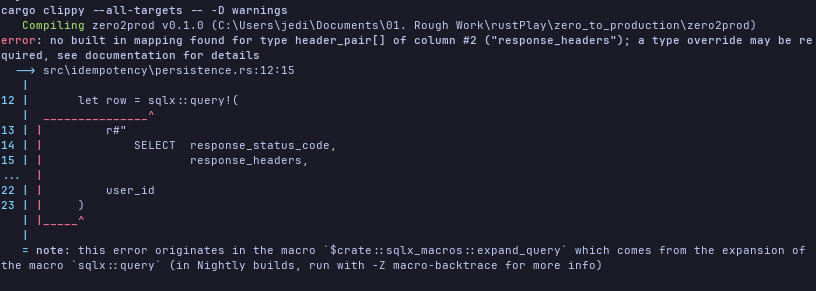

It might not be an in built mapping to `header_pair` out of the box, but there is a mechanism for us to specify how it should be handled  
the `Type`, `Decode` and `Encode` traits.  
There is a macro available to use that simplifies this for us. We just need to specify the type fields and name the composite type as it appears in Postgres. We'll also need  
to explicitly map `HeaderPairRecord` to the `response_headers` for sqlx to understand the underlying postgres type.

We can then go ahead and build the response to return if one exists.
```Rust
// src/idempotency/persistence.rs
// [...]

#[derive(Debug, sqlx::Type)]
#[sqlx(type_name = "header_pair")]
struct HeaderPairRecord {
    name: String,
    value: Vec<u8>,
}

pub async fn get_response(
    db_pool: &PgPool,
    idempotency_key: IdempotencyKey,
    user_id: Uuid,
) -> Result<Option<HttpResponse>, anyhow::Error> {
    let saved_response = sqlx::query!(
        r#"
            SELECT  response_status_code,
                    response_headers as "response_header: Vec<HeaderPairRecord>",
                    response_body
                FROM idempotency
            WHERE idempotency_key = $1
                AND user_id = $2;
        "#
        idempotency_key.as_ref(),
        user_id,
    )
    .fetch_optional(db_pool)
    .await?;

    if let Some(row) = saved_response {
        let status_code = StatusCode::from_u16(
            row.response_status_code.try_into()?
        )?;
        let mut response = HttpResponse::build(status_code);
        for HeaderPairRecord { name, value } in row.response_headers {
            response.append_headers((name, value))
        }
        Ok(Some(response.body(row.response_body)))
    } else {
        Ok(None)
    }
    
}
```

We can now plug it in to the `publish_newsletter` handler.
```Rust
// src/routes/admin/newsletter/post.rs
// [...]
use crate::idempotency::get_response;

// [...]

pub async fn publish_newsletter(/**/) -> Result</**/> {
    // [...]
    // Early return if we have a saved response in the database
    if let Some(response) = get_response(&db_pool, idempotency_key, user_id).await.map_err(e500)? {
        FlashMessage::error("Newsletter Issue Published Successfully.").send()
        return Ok(response);
    }
}
```

The code should compile.

### 11.8.3. Save Responses

##### 11.08.0.0. Skimming: What did you notice and why? Any Questions

**What?**  
- `.body()` is generic over `B` which defaults to `BoxBody` if no type is specified.
- `MessageBody` trait that must be implemented for any type that is intended to be used as a body in `actix-web`
- Because of streaming alternative we need an owned instance of `HttpResponse` which implements `MessageBody` that we breakdown using `into_parts`. We can then use
  `actix_web::body::into_bytes` to get type body type that we can store. We then have to reassemble the http response back using `set_body` on the headers to be able
  to return a HttpResponse
- `query_unchecked!` macro and `PgHasArrayType` trait for `HeaderPairRecord`

**Why?**  
- HTTP/1.1 specifies that a body can be fully-formed or streamed. `BoxBody` is an enum representing this strategy.
- How we dive into `response_body` details inorder to understand how best to parse it for storage then reassamble the it back for our user/client side HttpResponse
- We use `query_unchecked!` becuase `query!` is not powerful enough to check the query against our custom composite SQL type.
- We implement `PgHasArrayType` for `HeaderPairRecord` to provide sqlx with type information on our `header_pair` column.

**Questions?**  
- Was curious if `query!` is now powerful enough to use without having to disable compile-time verifcation using `query_unchecked`.  
Here's what I from [claude](https://claude.ai/share/8e0c3534-fe7d-4ee3-98e7-b18808a041cc).
> It truly amazing how much we are able to learn, discover, experiment with AI.


#### 11.8.3.0. Intro

##### 11.08.0.1. Deep Dive: Summarize, ELI5, Connect

_**Summary**_  
Now for the more involved part. Saving the http response to our database. Here we'll basically need to disassemble a http response in order to get the values to
store in our database. Then we re-assemble the http response as a return value.  
Let's take a closer look at `HttpResponse` to know how we'll disassemble it.
- For the status code we have a `.status()` method that returns a `StatusCode` type.
- For the headers we have a `.headers()` method that returns a `&HeaderMap` type.
- For the body we have a `.body()` type that returns a `&B` type.

For the first 2 its kinda straight forward how we can parse them
- `.status().as_u16()` as we've been doing in tests. However we then have to map it `as i16` to be postgres compatible.
- `.headers()` we take the key value pairs `name` and `value` and create `HeaderPairRecord` instances that we can push into a `Vec<HeaderPairRecord>` instance.
  > To handle the sqlx mapping we'll make use of a `sqlx.toml` file where we specify the type overrides as follows
  > 
  > ```TOML
  > # src/sqlx.toml
  > [macro.type_overrides]
  > 'header_pair' = "crate::idempotency::HeaderPairRecord"
  > 'header_pair[]' = "Vec<crate::idempotency::HeaderPairRecord>"
  > ```  
  > </br>
  > 
  > For this to work though you need to enalbe the `sqlx-toml` feature for the `sqlx_cli`

For the body how do we parse `&B` and what is it anyway?  
Turns out `HttpReponse` body is generic with the default value for `B` being `BoxBody`
```Rust
pub struct HttpResponse<B = BoxBody> {/**/}

impl<B> HttpResponse<B> {
    // [...]
    // Returns a reference to this response's body
    pub fn body(&self) -> &B {
        self.res.body()
    }
}
```

And what is `BoxBody`?
```Rust
#[derive(Debug)]
pub struct BoxBody(BoxBodyInner);

enum BoxBodyInner {
    None(body::None),
    Bytes(Bytes)
    Steam(Pin<Box<dyn MessageBody<Error = Box<dyn StdError>>>>)
}
```
Lets pause. Why all this for the response body?  
HTTP/1.1 supports 2 types of responses
- fully formed responses $\rightarrow$ which we have been working with
- streaming responses where a payload is broken down into multiple chunks as known as **HTTP streaming**
  > [`Transfer-Encoding: chunked`](https://developer.mozilla.org/en-US/docs/Web/HTTP/Reference/Headers/Transfer-Encoding)
  > commonly used for streaming video or audio.
  

With this in mind it becomes easier to understand the `MessageBody` trait.
```Rust
pub trait MessageBody {
    type Error: Into<Box<dyn Error + 'static, Global>>;
    fn poll_next(
        self: Pin<&mut Self>,
        cx: &mut Context<'_>
    ) -> Poll<Option<Result<Bytes, Self::Error>>>;
    // [...]
}
```
Now that we know that our full formed response body is returned as `Bytes`, `actix_web` provides a `to_bytes` function that calls `poll_next`
until there is no more data to fetch, returning a response back to us inside a `Bytes` container

With enough context lets now move into the implementation details of our `save_response` method.

**Implementation**  
```Rust
// src/idempotency/persistence.rs
// [...]
use actix_web::body::to_bytes;

pub async fn save_response(
    db_pool: &PgPool,
    idempotency_key: &IdempotencyKey,
    user_id: Uuid,
    http_response: HttpResponse,
) -> Result<HttpResponse, anyhow::Error> {
    // Disassemble
    let (response_head, body) = http_response.into_parts();
    let body = to_bytes(body).await.map_err(|e| anyhow::anyhow!("{}", e))?;
    let status_code = response_head.status().as_u16() as i16;
    let headers = {
        let mut h = Vec::with_capacity(response_head.headers().len());
        for (name, value) in response_head.headers().iter() {
            let name = name.to_string().to_owned();
            let value = value.to_bytes().to_owned();
            h.push(HeaderPairRecord{ name, value});
        } 
        h
    };
    // Insert
    sqlx::query!(
        r#"
            INSERT INTO idempotency (
                user_id,
                idempotency_key,
                response_status_code,
                response_headers,
                response_body
                created_at
            )
            VALUES ($1, $2, $3, $4, $5, now())
        "#,
        user_id,
        idempotency_key.as_ref(),
        status_code,
        headers as Vec<HeaderPairRecord>, // works because of the sqlx.toml type overrides we added.
        body.as_ref(),
    )
    .execute(db_pool)
    .await?;
    
    // Re-assemble
    let response = response_head.set_body(body).await.map_into_boxed_body();
    Ok(response)
}
```

#### 11.8.3.3. Plug it in

```Rust
// src/routes/admin/newletter/post.rs
// [...]

#[tracing::instrument(/**/)]
pub async fn publish_newsletter(/**/) -> Result</**/> {
    // [...]
    for sub in subscribers {
        // [...]
    }
    
    FlashMessage::info("Newsletter Issue Published Successfully.").send();
    let response = see_other("/admin/publish_newsletter");
    let response = save_response(&db_pool, &idempotency_key, user_id, response).await.map_err(e500)?;
    Ok(response)
}
```

With this our `newsletter_creation_is_idempotent` test should pass.

## 11.9. Concurrent Request

##### 11.09.0.0. Skimming: What did you notice and why? Any Questions

**What?**  
- **cross-request synchronization**
- We relax the `NOT NULL` constraints for our `response_` fields for us to be able to insert into the `indepotency` table before a response is returned.
- Postgres `ON CONFLICT` statement
- `as "response_[placeholder]!"`
- Different transaction isolation levels. Need to look more into this.
    - `"READ COMMITTED"`
    - `"SET TRANSACTION ISOLATION LEVEL repeatable read"`


**Why?**  
- What mechanism will we use to facilitate **cross-request synchronization**? Turns out we'll use _**transaction isolation levels**_ by sharing a transaction
  between our `INSERT` statement in `try_processing` and our `UPDATE` statement in `save_response`, ensuring our first request is only read after being fully processed, such that
  subsequent request either return what is already committed or `DO NOTHING` until the first transactions is complete.
- Seems like transaction isolation levels determine how data is read between an transactions.
    - `READ COMMITTED` only allows reads once data is committed
    - `REPEATABLE READ` does not allow non-repeatable read i.e resulting in an error if data changes between `INSERT` and `UPDATE`.
    - `SERIALIZABLE` the strictext isolation level available in Postgres.(To check what this means in the deep dive.)
     


**Questions?**
- Wondering if instead of `ON CONFLICT DO NOTHING` it would have been better to have a `indempotency_status` field that has `PENDING` and `SET`. I guess i understand
  why `DO NOTHING` is a better approach because, the first retry can update the status to `PENDING`. What about the second and the third. Leading to unnecessary writes
  or unnecessary branching logic.


##### 11.09.0.1. Deep Dive: Summarize, ELI5, Connect

**Summary**  
Alright we have solved for the "easy" idempotency scenario, where the original request is fully processed before the retry comes in.  
What about the concurrent case where a retry comes before the initial request if fully processed?  
We need to find a way to make the retry request to wait until the first request is processed and return its result on the retry.  
Essentially some kind of synchronization mechanism.

Let start by modelling the behavior we want with a test



### 11.9.1. Requirements As Tests #2

**Implementation**  
```Rust
// tests/api/newsletter.rs
// [...]
use std::time::Duration;

#[tokio::test]
async fn concurrent_form_submission_is_handled_gracefully() {
    // Arrange
    let app = spawn_app().await;
    app.test_user.login(&app).await;
    create_confirmed_user(&app).await;

    // Act
    Mock::given(path("/email"))
        .and(method("POST"))
        .respond_with(ResponseTemplate::new(200).set_delay(Duration::from_secs(2)))
        .expect(1)
        .mount(&app.email_server)
        .await

    let newsletter_publish_request = serde_json::json!({
        "title": "Newsletter title",
        "txt_content": "Newsletter content",
        "idempotency_key": Uuid::now_v7().to_string(),
    });
    let response1 = app.post_publish_newsletter(&newsletter_publish_request);
    let response2 = app.post_publish_newsletter(&newsletter_publish_request);
    let (response1, response2) = tokio::join!(response1, response2);

    // Assert
    assert_eq!(response1.status().as_u16(), response2.status().as_u16());
    assert_eq!(response1.text().await.unwrap(), response2.text().await.unwrap());
}
```

The test will fail.

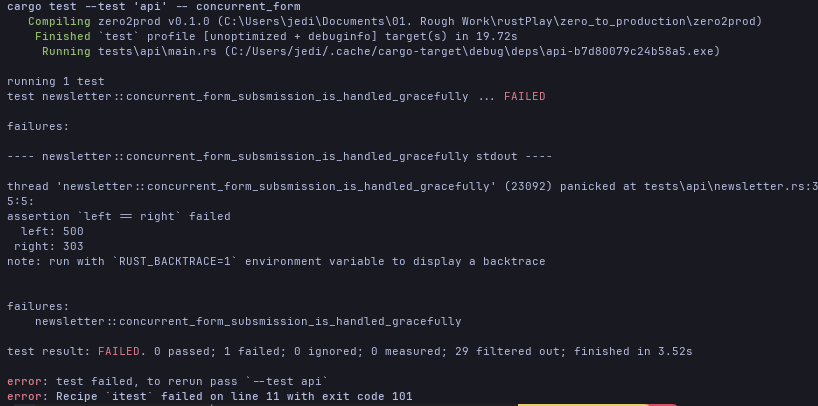

Inspecting the logs we get the to the cause.

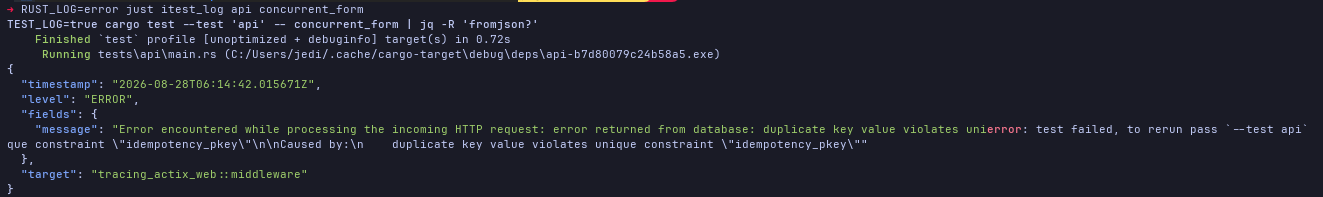

### 11.9.2. Synchronization

To get our test to pass we need to update our implementaion in the following way.  
1. Split adding an idempotency table entry into;
    - Initial slim insertion with `use_id` and `idempotency`.
    - Updating the response fields for idempotency after the initial request was processed.
2. We have to relax the null constraints for the response fields for the idempotency table so as to be able to have the as null intially and
   then update them later.

To do this successfully we'll need to make use of transactions and transaction isolation levels as our way for us to achieve synchronicity.  
1. `ON CONFLICT DO NOTHING` allows to do handle when the rety duplicate db insertion comes next.
2. Having the insertion and update in the same transaction means that they both happen succesfully or not at all, and the default isolation
   `READ COMMITTED` works in our favor because our `get_response` will only read what has been committed.

**Implementation**  
Let's start by adding a migration to relax the null checks for the reponse field on the idempotency table.
```bash
sqlx migrate add relax_response_fields_null_checks_for_idempotency
```
```SQL
ALTER TABLE idempotency ALTER COLUMN response_status_code DROP NOT NULL;
ALTER TABLE idempotency ALTER COLUMN response_headers DROP NOT NULL;
ALTER TABLE idempotency ALTER COLUMN response_body DROP NOT NULL;
```
```bash
sqlx migrate run
```

We then need to update our `get_saved_response` for the possible null response fields.
```Rust
// src/idempotency/persistence.rs
// [...]

// [...]

async fn get_saved_response(
    db_pool: &PgPool,
    idempotency_key: &IdempotencyKey,
    user_id: Uuid,
) -> Result<Option<HttpResponse>, anyhow::Error> {
    // [...]
    let saved_response = sqlx::query!(
        r#"
            SELECT  response_status_code as "response_status_code!", 
                    response_headers as "response_headers!: Vec<HeaderPairRecord>",
                    response_body as "response_body!"
                FROM idempotency
            WHERE 
                idempotency_key = $1 AND
                user_id = $2;
        "#
        idempotency_key.as_ref(),
        user_id
    )
    .fetch_optional(db_pool)
    .await?;
    // [...]
}

```

Next, lets split the initial insertion from the later update once we get a response.  
1. The initial insertion will be done through `try_processing`. Also manage state through a `NextAction`
   enum where if we already have a response we return it and if we haven't we kick off processing it.
2. We'll need to update `save_response` from inserting to updating the table with response values.

```Rust
// src/idempotency/persistence.rs
// [...]
use sqlx::{Transaction, Postgres};

#[derive(Debug)]
pub enum NextAction {
    StartProcessing(Transaction<'static, Postgres>),
    ReturnSavedResponse(HttpResponse),
}

pub async fn try_processing(
    db_pool: &PgPool,
    idempotency_key: &IdempotencyKey,
    user_id: Uuid,
) -> Result<NextAction, anyhow::Error> {
    let mut transaction = db_pool.begin().await;
    let query = sqlx::query!(
        r#"
            INSERT INTO idempotency (
                user_id,
                idempotency_key,
                created_at
            )
            VALUES ($1, $2, now())
            ON CONFLICT DO NOTHING;
        "#,
        user_id,
        idempotency_key.as_ref(),
    );
    let n_inserted_rows = transaction
        .execute(query)
        .await?
        .rows_affected();
    if n_inserted_rows > 0 {
        Ok(NextAction::StartProcessing(transaction))
    } else {
        let saved_response = get_saved_response(db_pool, &idempotency_key, user_id)
            .await?
            .ok_or_else(|| anyhow::anyhow!("Expected to get saved response, but none was found."))?;
        Ok(NextAction::ReturnSavedResponse(saved_response))
    }
}

// [...]

pub async fn save_response(
    mut transaction: Transaction<'static, Postgres>,
    idempotency_key: &IdempotencyKey,
    user_id: Uuid,
    http_response: HttpResponse,
) -> Result<HttpResponse, anyhow::Error> {
    // [...]
    let query = sqlx::query!(
        r#"
            UPDATE idempotency
            SET  
                response_status_code = $1,
                response_headers = $2,
                response_body = $3
            WHERE 
                idempotency_key = $4,
                user_id = $5;
        "#,
        status_code,
        headers as Vec<HeaderPairRecord>,
        body.as_ref(),
        idempotency_key.as_ref(),
        user_id
    );
    transaction.execute(query).await?;
    transaction.commit().await?;

    let response = response_head.set_body(body).map_into_boxed_body();
    Ok(response)
}
```

The we plug it in.
```Rust
// src/routes/admin/newsletter/post.rs
// [...]
use crate::idempotency::try_processing;

#[tracing::instrument(/**/)]
pub async fn publish_newsletter(/**/) -> Result</**/> {
    // [...]
    let transaction = match try_processing(&db_pool, &idempotency_key, user_id)
        .await
        .map_err(e500)? 
    {
        NextAction::StartProcessing(t) => t,
        NextAction::ReturnSavedResponse(saved_response) => {
            FlashMessage::("Newsletter Issue Published Successfully.").send()
            return Ok(response);
        }
    };
    
    // [...]
    
    let response = save_response(transaction, &idempotency_key, user_id, response)
        .await
        .map_err(e500)?; 
    Ok(response)
}
```

With everything wired up correctly our test should pass.

## 11.10. Dealing With Errors (Slightly Bulky)

##### 11.10.0.0. Skimming: What did you notice and why? Any Questions

**What?**  
- We call `when_sending_email()` 3 times
- The second `when_sending_email()` returns an intentional 500
- Recovery strategies
    - Backward recovery - semantic rollback via **compensating actions**.
    - Forward recovery - driving the overall workflow untill completion
        - Passive - Application takes snapshots and user is responsible for driving the workflow when failure occurs
        - Active - Application self heals **asynchronously** relying on background processes/task that drive the workflow to completion
          without user interaction
- Recovering transactionality by having retriaval of subscriber data, creating idempotency records processing task queue in a single transaction
  where they all succeed or nothing happened.
- Combined `INSERT` AND `SELECT` in `enqueue_delivery_tasks` where we insert `issue_delivery_queue` items in one go with the results of the subquery.
- No email sending in `publish_newsletter` handler now.
- `FOR UPDATE` and `SKIP LOCKED` for selecting only the enqueued items that are not already being processed.
- We do not retry when delivery fails due to a Postmark error. Left as an exercise for the reader
- We also need to
    - refine retries to work with a exponential backoff and jitters in the event of transient failures
    - refine `try_execute_tasks` implememntation that has both transient and non transient errors empowering `worker_loop` to react appropriately. 
- Running the application and the background task in concurrently and in parallel using `tokio::spawn` and `tokio::select`
- `client()` method for `EmailClientSettings` is config + updating all our email sending workflows to using `dispatch_all_pendings_emails` helper method.
- This means we are building the client in `config.rs` and then calling to get an `email_client` in `build.rs`
- Note the difference between `email_client` new struct field in `TestApp` vs `email_server` that is our mock server. Also note the difference between
  `client` which is our web client/application client vs `email_client` which is for our postmark mocking.


**Why?**  
- Curious if the multiple mock server call represents sending an email to each test subscriber.
- Was missing why the comment wasy saying `// Email delivery fails for the second subscriber`.
- I have a better understanding of the reason behind background tasks.
- Feels like seeing what happens behind the curtain to see how fault-tolerance is actually implemented.
- Nice application of subsqueries.
- Concurrency-safe queue via `FOR UPDATE` and `SKIP LOCKED`.
- On demand email worker approach in test as opposed to mimicing the background worker as in our application implementation, to avoid a fragile test suite
  where, for instance we have to set abitrary seep time intervals waiting for the background worker to process email tasks we've just enqueued.


**Questions?**  
- Time implication of parsing text content into html content in process vs persisting html content. Feels like that might be redudant data and not properly
  normalizing the database.
  > From a performance standpoint we'd be storing the html content once when the author clicks submit. If we generate the html content at send, we'd be generating html for every send. Of course currently the numbers are small enough not to matter, but other issues are still at play here.
  >  - Persisting the html content is more reproducible
  >  - If issue occur when persisting the html content the user is notified. While at email send if the html content is not valid the subscribers get garbage data.
- I wonder how node, django, fast api handle both application and background tasks. Do the only use asynchronous concurrency on a single thread or do they have
  a parallelism mechanism to be able to do both




##### 11.10.0.1. Deep Dive: Summarize, ELI5, Connect

### 11.10.0. Overview

### 11.10.1. Distrubuted Transactions

### 11.10.2. Backward Recovery

### 11.10.3. Forward Recovery

### 11.10.0. Asynchronous Processing

## 11.x. Epilogue

## 11.12. Axum Implementation Notes. 